# Data Analysis with Python
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## Importing necessary packages
It is common to import the necessary packages for data analysis at the beginning of the notebook.

In [ ]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from pprint import pprint
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from PIL import Image
import re

print(np.__version__)
print(pd.__version__)



2.0.2
2.2.2


## Data loading or Fetching
Here we can acquire the data. It could be from API, database or from a dataset.

In [ ]:
def fetch_data(url):
  response = requests.get(url)
  data = response.json()
  return data


url = 'https://api.thecatapi.com/v1/breeds'
data = fetch_data(url)
pprint(data[0])



{'adaptability': 5,
 'affection_level': 5,
 'alt_names': '',
 'breed_group': None,
 'cfa_url': 'http://cfa.org/Breeds/BreedsAB/Abyssinian.aspx',
 'child_friendly': 3,
 'country_code': 'EG',
 'country_codes': 'EG',
 'description': 'The Abyssinian is easy to care for, and a joy to have in your '
                'home. They’re affectionate cats and love both people and '
                'other animals.',
 'dog_friendly': 4,
 'energy_level': 5,
 'experimental': 0,
 'grooming': 1,
 'hairless': 0,
 'health_issues': 2,
 'hypoallergenic': 0,
 'id': 'abys',
 'indoor': 0,
 'intelligence': 5,
 'lap': 1,
 'life_span': '14 - 15',
 'name': 'Abyssinian',
 'natural': 1,
 'origin': 'Egypt',
 'rare': 0,
 'reference_image_id': '0XYvRd7oD',
 'rex': 0,
 'shedding_level': 2,
 'short_legs': 0,
 'social_needs': 5,
 'stranger_friendly': 5,
 'suppressed_tail': 0,
 'temperament': 'Active, Energetic, Independent, Intelligent, Gentle',
 'vcahospitals_url': 'https://vcahospitals.com/know-your-pet/cat-breeds/abyssin

In [ ]:
'''
What is the average life span of a cat?
What is the min, max and  average weight of a cat?
Which country has more cat breeds?
'''
def find_average_lifespan_cat():
  cats_minimum_life_span = []
  cats_maximum_life_span = []
  cats_average_life_span = []

  for cat in data:
    # print(cat['name'],' - ', cat['origin'], cat['life_span'])
    life_spans = cat['life_span'].split(' - ')
    min_life_span = int(life_spans[0])
    max_life_span = int(life_spans[1])
    cats_minimum_life_span.append(min_life_span)
    cats_maximum_life_span.append(max_life_span)
    average = (min_life_span + max_life_span) / 2
    cats_average_life_span.append(average)
  print('cats_minimum_life_span:', min(cats_minimum_life_span))
  print('cats_maximum_life_span:', max(cats_maximum_life_span))
  average = sum(cats_average_life_span) / len(cats_average_life_span)
  print('cats_average_life_span:', round(average, 2) )
  find_average_lifespan_cat()


In [ ]:
# Which country has more cat breeds?
def create_country_origin_freq_table():
  origins = {}
  for cat in data:
    origin = cat['origin']
    if origin in origins:
      origins[origin] += 1
    else:
      origins[origin] = 1
  items = origins.items()
  sorted_items = sorted(items, key = lambda item:item[1], reverse = True)
  countries = []
  values = []

  for items in sorted_items:
    country = items[0]
    value = items[1]
    countries.append(country)
    values.append(value)
  return countries, values

  # print(countries)
  # print(values)

  ''' for country, value in sorted_items:
    countries.append(country)
    values.append(value)

  print(countries)
  print(values) '''

create_country_origin_freq_table()




(['United States',
  'United Kingdom',
  'Russia',
  'Thailand',
  'Egypt',
  'Canada',
  'France',
  'Burma',
  'Turkey',
  'Greece',
  'United Arab Emirates',
  'Australia',
  'Cyprus',
  'China',
  'Japan',
  'Isle of Man',
  'Norway',
  'Iran (Persia)',
  'Singapore',
  'Somalia'],
 [28, 8, 4, 4, 3, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

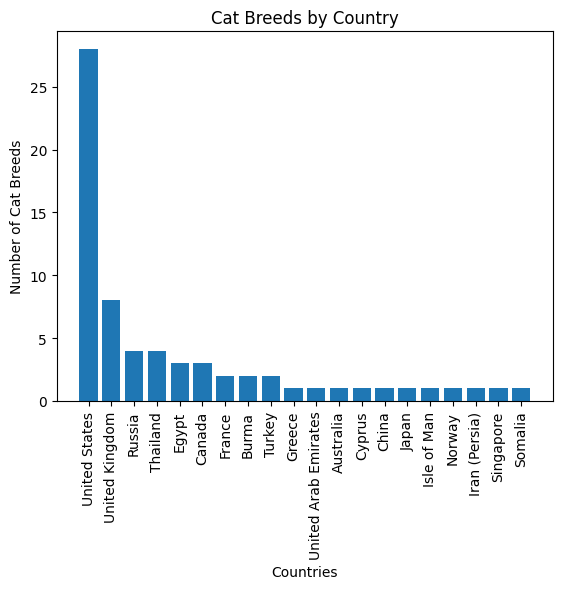

In [ ]:
# Data Visualization
countries, values= create_country_origin_freq_table()

plt.bar(countries, values)
plt.xlabel('Countries')
plt.ylabel('Number of Cat Breeds')
plt.title('Cat Breeds by Country')
plt.xticks(rotation=90)
plt.savefig('cat_breeds_by_country_vertical.png')
plt.show()

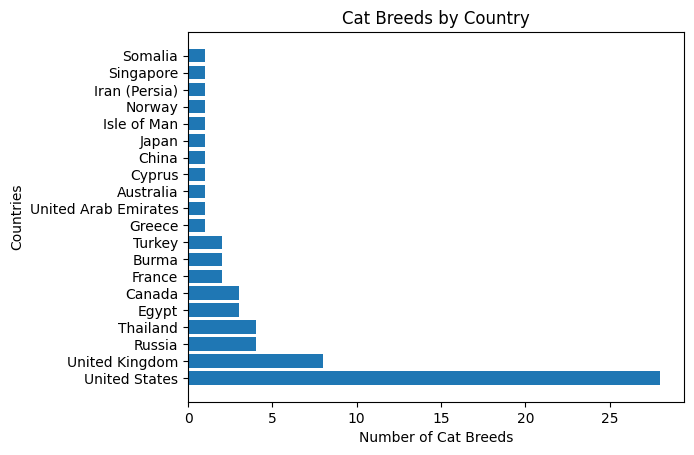

In [ ]:
plt.barh(countries, values)
plt.ylabel('Countries')
plt.xlabel('Number of Cat Breeds')
plt.title('Cat Breeds by Country')
plt.savefig('cat_breeds_by_country_horizontal.png')
plt.show()

## World Cloud

In [ ]:
words = []
for cat in data:
  pattern = r'[^a-zA-Z\s]'
  description = re.sub(pattern, '', cat['description'])
  words.extend(description.lower().split())
pprint(words[:10])

['the', 'abyssinian', 'is', 'easy', 'to', 'care', 'for', 'and', 'a', 'joy']


In [ ]:
def create_freq_table(n = None):
  freq_table = {}
  for word in words:
    if word not in ENGLISH_STOP_WORDS:
      if word in freq_table:
        freq_table[word] += 1
      else:
        freq_table[word] = 1

  items = freq_table.items()
  sorted_items = sorted(items, key = lambda item:item[1], reverse = True)
  if n is None:
    return sorted_items
  else:
    return sorted_items[:n]

create_freq_table(10)


[('cat', 44),
 ('people', 29),
 ('intelligent', 20),
 ('love', 19),
 ('affectionate', 18),
 ('cats', 18),
 ('lap', 18),
 ('loving', 13),
 ('breed', 12),
 ('companion', 12)]

['cat', 'people', 'intelligent', 'love', 'affectionate', 'cats', 'lap', 'loving', 'breed', 'companion']
[44, 29, 20, 19, 18, 18, 18, 13, 12, 12]


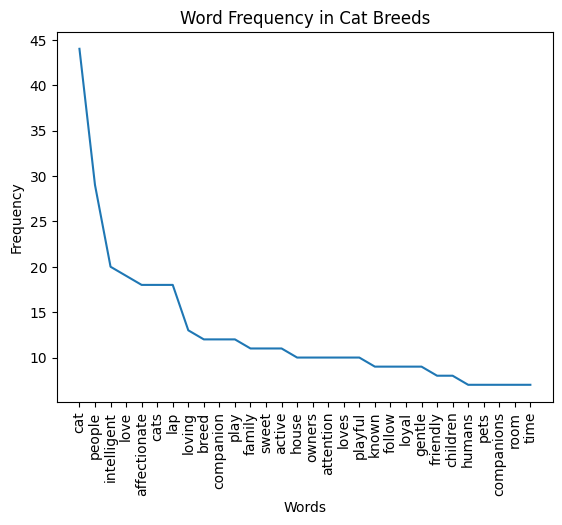

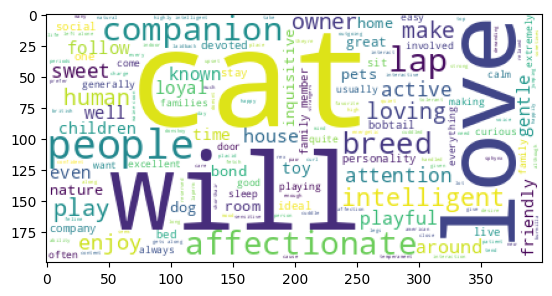

In [ ]:
def separate_keys_values(sorted_items):
  keys = []
  values = []
  for key, value in sorted_items:
    keys.append(key)
    values.append(value)
  return keys, values


sorted_items = create_freq_table()
keys, values = separate_keys_values(sorted_items)
print(keys[:10])
print(values[:10])

plt.plot(keys[:30], values[:30])
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Word Frequency in Cat Breeds')
plt.xticks(rotation=90)
plt.savefig('word_frequency_in_cat_breeds.png')
plt.show()


wordcloud = WordCloud(background_color='white').generate(' '.join(words))
plt.imshow(wordcloud)
plt.axis('on')
plt.savefig('word_cloud_cat_breeds.png')
plt.show()



In [ ]:
print(len(STOPWORDS), len(ENGLISH_STOP_WORDS))

192 318


In [ ]:
url = 'https://studies.cs.helsinki.fi/restcountries/api/all'
countries = fetch_data(url)

In [ ]:
pprint(countries[0])

{'altSpellings': ['KW', 'State of Kuwait', 'Dawlat al-Kuwait'],
 'area': 17818,
 'borders': ['IRQ', 'SAU'],
 'capital': ['Kuwait City'],
 'capitalInfo': {'latlng': [29.37, 47.97]},
 'car': {'side': 'right', 'signs': ['KWT']},
 'cca2': 'KW',
 'cca3': 'KWT',
 'ccn3': '414',
 'cioc': 'KUW',
 'coatOfArms': {'png': 'https://mainfacts.com/media/images/coats_of_arms/kw.png',
                'svg': 'https://mainfacts.com/media/images/coats_of_arms/kw.svg'},
 'continents': ['Asia'],
 'currencies': {'KWD': {'name': 'Kuwaiti dinar', 'symbol': 'د.ك'}},
 'demonyms': {'eng': {'f': 'Kuwaiti', 'm': 'Kuwaiti'},
              'fra': {'f': 'Koweïtienne', 'm': 'Koweïtien'}},
 'fifa': 'KUW',
 'flag': '🇰🇼',
 'flags': {'alt': 'The flag of Kuwait is composed of three equal horizontal '
                  'bands of green, white and red, with a black trapezium '
                  'superimposed on the hoist side of the field. This trapezium '
                  'has its base on the hoist end and spans about one-fo

In [ ]:
for country in countries:
  print(country['name']['common'], country['population'])
  if 'capital' in country:
    print(country['capital'][0])
  else:
    print('No capital')
  print('===========')


Kuwait 4270563
Kuwait City
Austria 8917205
Vienna
Mayotte 226915
Mamoudzou
Tunisia 11818618
Tunis
Japan 125836021
Tokyo
Guyana 786559
Georgetown
Saint Helena, Ascension and Tristan da Cunha 53192
Jamestown
Saint Martin 38659
Marigot
Guatemala 16858333
Guatemala City
Venezuela 28435943
Caracas
French Southern and Antarctic Lands 400
Port-aux-Français
Cape Verde 555988
Praia
Azerbaijan 10110116
Baku
Guernsey 62999
St. Peter Port
Kenya 53771300
Nairobi
South Sudan 11193729
Juba
Myanmar 54409794
Naypyidaw
Liechtenstein 38137
Vaduz
Martinique 378243
Fort-de-France
Australia 25687041
Canberra
Costa Rica 5094114
San José
Palestine 4803269
Ramallah
Spain 47351567
Madrid
Guinea-Bissau 1967998
Bissau
Åland Islands 29458
Mariehamn
Sierra Leone 7976985
Freetown
Philippines 109581085
Manila
Togo 8278737
Lomé
Russia 144104080
Moscow
Haiti 11402533
Port-au-Prince
South Korea 51780579
Seoul
Samoa 198410
Apia
Aruba 106766
Oranjestad
Afghanistan 40218234
Kabul
Bouvet Island 0
No capital
Bahamas 393248
N

In [ ]:
# Dogs API
url = 'https://dogapi.dog/api/v2/breeds'
dogs = fetch_data(url)

In [ ]:
dogs['data'][0]

{'id': '036feed0-da8a-42c9-ab9a-57449b530b13',
 'type': 'breed',
 'attributes': {'name': 'Affenpinscher',
  'description': 'The Affenpinscher is a small and playful breed of dog that was originally bred in Germany for hunting small game. They are intelligent, energetic, and affectionate, and make excellent companion dogs.',
  'life': {'max': 16, 'min': 14},
  'male_weight': {'max': 5, 'min': 3},
  'female_weight': {'max': 5, 'min': 3},
  'hypoallergenic': True},
 'relationships': {'group': {'data': {'id': 'f56dc4b1-ba1a-4454-8ce2-bd5d41404a0c',
    'type': 'group'}}}}